# `cos_pricing` tests, as a notebook

Same assertions as `pytest tests/`, just laid out in reading order with
a short note before each block and a table of actual numbers after.
Runs top-to-bottom — any failure will raise right where it happens
instead of being rolled up into a pytest summary.

Sections 1-4 are the test suite. Section 5 reproduces the headline
figures from the README in live code. Section 6 sweeps the main
hyperparameters of each pricer and charts how error and runtime move.

Where the tests come from:

| Section | File | Covers |
|---|---|---|
| 1 | `test_cos_method.py` | BSM COS, pinned against the closed form |
| 2 | `test_heston_cos_pricer.py` | Heston against Fang-Oosterlee benchmarks |
| 3 | `test_vg_model.py` | Variance Gamma: CF, Table 7, Carr-Madan, density |
| 4.1-4.2 | `test_dimensional_invariance.py` | BSM scale / Bachelier translation |
| 4.3 | `test_buckingham_pi.py` | Parametrised pi-symmetry across pricers |
| 4.4-4.5 | `test_heston_temporal_invariance.py` | Heston temporal + joint spatial x temporal |
| 5 | README figures | Table 1/2/3 + dimensionless collapse plots |
| 6 | this notebook | Error / runtime vs hyperparameters per pricer |


## Setup

`cos_pricing` lives under `src/`, so we prepend it to `sys.path` to avoid
needing a dev install or `PYTHONPATH=src`. Everything else is standard
scipy/pandas/matplotlib.

In [1]:
import os, sys, time
ROOT = os.path.abspath(os.path.join(os.getcwd(),
    ".." if os.path.basename(os.getcwd()) == "notebooks" else "."))
sys.path.insert(0, os.path.join(ROOT, "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3d projection
from scipy.stats import linregress, norm

from cos_pricing import (
    BsmModel, NormalCos, HestonCOSPricer, VgModel,
    bsm_price, cos_price, carr_madan_price,
)

pd.set_option("display.float_format", lambda x: f"{x:.10g}")
plt.rcParams["figure.dpi"] = 100
print("imports OK")

imports OK


---
# 1. BSM COS method

BSM is the anchor. It's the only model here with a closed form, so if
the COS output doesn't match `bsm_price` to roughly 1e-10, something
obvious is broken — either the kernel, the CF, or the truncation. The
rest of the library generalises this code path, so this file is where
bugs get cheapest to find.

In [2]:
bsm_params = dict(sigma=0.2, intr=0.05, divr=0.1)
m_bsm      = BsmModel(**bsm_params)

## 1.1 &nbsp; Agreement with the closed form

Three probes — an ATM call, a slightly-OTM put, and a vectorised
sweep across five strikes. Expected error is essentially machine
precision.

In [3]:
rows = []

# single ATM call
cos_v = m_bsm.price(100.0, 100.0, 1.0, cp=1)
ref   = bsm_price(100.0, 100.0, bsm_params["sigma"], 1.0,
                  bsm_params["intr"], bsm_params["divr"], cp=1)
rows.append(("call", 100.0, 1.0, cos_v, ref, abs(cos_v - ref)))
assert abs(cos_v - ref) < 1e-10

# single OTM put
cos_v = m_bsm.price(105.0, 100.0, 1.0, cp=-1)
ref   = bsm_price(105.0, 100.0, bsm_params["sigma"], 1.0,
                  bsm_params["intr"], bsm_params["divr"], cp=-1)
rows.append(("put", 105.0, 1.0, cos_v, ref, abs(cos_v - ref)))
assert abs(cos_v - ref) < 1e-10

# vectorised strike sweep
strikes = np.arange(80, 121, 10, dtype=float)
cos_vs  = m_bsm.price(strikes, 100.0, 1.2)
refs    = bsm_price(strikes, 100.0, bsm_params["sigma"], 1.2,
                    bsm_params["intr"], bsm_params["divr"])
for k, cv, rv in zip(strikes, cos_vs, refs):
    rows.append(("call", float(k), 1.2, float(cv), float(rv), float(abs(cv - rv))))
assert np.max(np.abs(cos_vs - refs)) < 1e-10

pd.DataFrame(rows, columns=["cp", "K", "T", "COS", "BSM closed-form", "|err|"])

,cp,K,T,COS,BSM closed-form,|err|
0,call,100,1,5.301701951,5.301701951,1.003641614e-13
1,put,105,1,13.1820482,13.1820482,1.776356839e-15
2,call,80,1.2,15.71361973,15.71361973,8.171241461e-14
3,call,90,1.2,9.692508028,9.692508028,2.842170943e-14
4,call,100,1.2,5.529485456,5.529485456,3.819167205e-14
5,call,110,1.2,2.945583384,2.945583384,1.296740493e-13
6,call,120,1.2,1.481391315,1.481391315,4.662936703e-14


## 1.2 &nbsp; Put-call parity and a mixed `cp` array

Parity is a property of prices, not of the pricer — the call and put
machinery share a lot of code, so if they're subtly disagreeing on
coefficients the residual will show. Mixed `cp` (some +1, some −1) is
really a broadcasting test: strike array and cp array of the same shape
should do the right thing.

In [4]:
# parity: C - P == df * (F - K)
parity_rows = []
for K in [90.0, 100.0, 110.0]:
    c   = m_bsm.price(K, 100.0, 1.0, cp=+1)
    p   = m_bsm.price(K, 100.0, 1.0, cp=-1)
    fwd = 100.0 * np.exp((bsm_params["intr"] - bsm_params["divr"]) * 1.0)
    df  = np.exp(-bsm_params["intr"] * 1.0)
    parity_rows.append((K, c, p, df * (fwd - K), (c - p) - df * (fwd - K)))
    assert abs((c - p) - df * (fwd - K)) < 1e-10

parity_df = pd.DataFrame(parity_rows, columns=["K", "C", "P", "df*(F-K)", "residual"])

# mixed cp broadcasting
strikes = np.array([90.0, 95.0, 100.0, 105.0, 110.0])
cp      = np.array([-1,   -1,    1,     1,     1])
cos_v   = m_bsm.price(strikes, 100.0, 1.0, cp=cp)
ref     = bsm_price(strikes, 100.0, bsm_params["sigma"], 1.0,
                    bsm_params["intr"], bsm_params["divr"], cp=cp)
mixed_df = pd.DataFrame({"K": strikes, "cp": cp, "COS": cos_v,
                         "ref": ref, "|err|": np.abs(cos_v - ref)})
assert np.max(np.abs(cos_v - ref)) < 1e-10

print("put-call parity:")
display(parity_df)
print("mixed cp broadcasting:")
mixed_df

put-call parity:


,K,C,P,df*(F-K),residual
0,90,9.716013847,4.842920248,4.873093599,6.838973832e-14
1,100,5.301701951,9.940902597,-4.639200646,1.10134124e-13
2,110,2.65002643,16.80152132,-14.15149489,2.664535259e-14


mixed cp broadcasting:


,K,cp,COS,ref,|err|
0,90,-1,4.842920248,4.842920248,1.598721155e-14
1,95,-1,7.14456262,7.14456262,2.664535259e-14
2,100,1,5.301701951,5.301701951,1.136868377e-13
3,105,1,3.786700434,3.786700434,1.776356839e-15
4,110,1,2.65002643,2.65002643,3.286260153e-14


## 1.3 &nbsp; Convergence in `n_cos`, shapes, and tail behaviour

A small N should be visibly wrong. Convergence is fast — N=64 already
hits machine precision for BSM. Scalar in, scalar out; array in, array
out. Deep-OTM call prices to basically zero, deep-ITM call prices to
the discounted intrinsic.

In [5]:
ref = bsm_price(100, 100, bsm_params["sigma"], 1.0,
                bsm_params["intr"], bsm_params["divr"])

conv_rows = []
for N in [4, 8, 16, 32, 64, 128]:
    err = abs(m_bsm.price(100, 100, 1.0, n_cos=N) - ref)
    conv_rows.append((N, err))
assert abs(m_bsm.price(100, 100, 1.0, n_cos=8)  - ref) > 1e-3
assert abs(m_bsm.price(100, 100, 1.0, n_cos=64) - ref) < 1e-10

# shape contracts
scalar_out = m_bsm.price(100.0, 100.0, 1.0)
array_out  = m_bsm.price(np.linspace(90, 110, 7), 100.0, 1.0)
assert isinstance(scalar_out, float)
assert array_out.shape == (7,)

# deep OTM / ITM
otm = m_bsm.price(200.0, 100.0, 1.0, cp=1)
fwd = 100.0 * np.exp((bsm_params["intr"] - bsm_params["divr"]) * 1.0)
df  = np.exp(-bsm_params["intr"] * 1.0)
itm = m_bsm.price(50.0, 100.0, 1.0, cp=1)
assert 0.0 <= otm < 0.01
assert abs(itm - df * (fwd - 50.0)) < 0.01

print(f"scalar in -> scalar out: {type(scalar_out).__name__},  "
      f"array in -> shape {array_out.shape}")
print(f"deep OTM (K=200): {otm:.3e}   deep ITM (K=50): {itm:.4f}  "
      f"vs df*(F-K)={df*(fwd-50.0):.4f}")
pd.DataFrame(conv_rows, columns=["n_cos", "|err|"])

scalar in -> scalar out: float,  array in -> shape (7,)
deep OTM (K=200): 6.342e-04   deep ITM (K=50): 42.9246  vs df*(F-K)=42.9223


,n_cos,|err|
0,4,25.74906154
1,8,4.352953006
2,16,0.239425862
3,32,0.0001107838807
4,64,1.003641614e-13
5,128,1.003641614e-13


## 1.4 &nbsp; Model-agnostic engine

`cos_price` is supposed to work for any CF, not just the one
`BsmModel` hands it. Feed in a hand-written BSM CF and an explicit
truncation range and verify the price still lands on the analytic
answer.

In [6]:
rows = []

# hand-rolled BSM CF
sigma, texp = 0.3, 1.0
def cf(u): return np.exp(-0.5 * sigma**2 * texp * u * (u + 1j))
p_cos = cos_price(cf, texp, 100.0, 100.0, 1.0, cp=1, n_cos=128,
                  trunc_range=(-5.0, 5.0))
p_ref = bsm_price(100.0, 100.0, sigma, texp)
rows.append(("custom CF",         p_cos, p_ref, abs(p_cos - p_ref)))
assert abs(p_cos - p_ref) < 1e-6

# explicit trunc_range on a model CF
cf2 = BsmModel(sigma=0.2).char_func(1.0)
p_cos = cos_price(cf2, 1.0, 100.0, 100.0, 1.0, cp=1,
                  n_cos=128, trunc_range=(-3.0, 3.0))
p_ref = bsm_price(100.0, 100.0, 0.2, 1.0)
rows.append(("explicit trunc",    p_cos, p_ref, abs(p_cos - p_ref)))
assert abs(p_cos - p_ref) < 1e-6

pd.DataFrame(rows, columns=["case", "cos_price", "BSM closed-form", "|err|"])

,case,cos_price,BSM closed-form,|err|
0,custom CF,11.92353847,11.92353847,1.099564884e-12
1,explicit trunc,7.965567455,7.965567455,1.030286967e-13


---
# 2. Heston COS pricer

No closed form, so the benchmarks come from Fang & Oosterlee (2008) —
two reference prices at T=1 and T=10 quoted to nine-plus significant
figures. Everything else in this section is either a convergence
exercise, a structural property that any reasonable pricer has to
satisfy, or an input-validation sweep.

The parameters below are the paper's Eq. 55 set (r = q = 0).

In [7]:
PAPER_PARAMS = dict(
    S0=100.0, v0=0.0175, lam=1.5768, eta=0.5751, ubar=0.0398, rho=-0.5711,
    r=0.0, q=0.0,
)
REF_T1, REF_T10 = 5.785155435, 22.318945791474590
m_hes = HestonCOSPricer(**PAPER_PARAMS)

## 2.1 &nbsp; Paper benchmarks

Reproduce the two published prices. Tolerances: 1e-5 at T=1, 1e-6 at
T=10.

In [8]:
p1  = m_hes.price_call(100.0, 1.0,  N=160)
p10 = m_hes.price_call(100.0, 10.0, N=160)
assert abs(p1  - REF_T1)  < 1e-5
assert abs(p10 - REF_T10) < 1e-6

pd.DataFrame([("T=1",  p1,  REF_T1,  abs(p1  - REF_T1)),
              ("T=10", p10, REF_T10, abs(p10 - REF_T10))],
             columns=["case", "COS (N=160)", "paper", "|err|"])

,case,COS (N=160),paper,|err|
0,T=1,5.785155481,5.785155435,4.608909343e-08
1,T=10,22.31894579,22.31894579,8.042988497e-10


## 2.2 &nbsp; Convergence in N and sensitivity to L

Two knobs. N is the cosine-series cutoff — more terms, less
truncation-in-frequency error. L sets the integration half-width in
log-moneyness; L=3 is way too narrow for Heston and gets dominated by
truncation-in-space. Default L=12 gives a few decimals of headroom.

In [9]:
# N refinement
N_rows = []
for N in (16, 32, 64, 128, 256):
    err = abs(m_hes.price_call(100.0, 1.0, N=N) - REF_T1)
    N_rows.append((N, err))
errs = [r[1] for r in N_rows]
for prev, curr in zip(errs, errs[1:]):
    assert curr <= prev * 1.1 + 1e-12
assert errs[-1] < 1e-6

# L sensitivity at fixed N=160
L_rows = []
for L in (3.0, 6.0, 9.0, 12.0):
    err = abs(m_hes.price_call(100.0, 1.0, N=160, L=L) - REF_T1)
    L_rows.append((L, err))
err_small = abs(m_hes.price_call(100.0, 1.0, N=160, L=3.0)  - REF_T1)
err_good  = abs(m_hes.price_call(100.0, 1.0, N=160, L=12.0) - REF_T1)
assert err_small > 1e3 * err_good
assert err_good  < 1e-6

print("Refinement in N (L at default):")
display(pd.DataFrame(N_rows, columns=["N", "|err|"]))
print("Sensitivity to L (N=160):")
pd.DataFrame(L_rows, columns=["L", "|err|"])

Refinement in N (L at default):


,N,|err|
0,16,0.6706095615
1,32,0.05363161147
2,64,0.0005784520695
3,128,5.358176489e-07
4,256,2.318403247e-09


Sensitivity to L (N=160):


,L,|err|
0,3,0.005855564733
1,6,1.383651971e-05
2,9,2.199506444e-08
3,12,2.921156632e-07


## 2.3 &nbsp; Structural properties

Four cheap structural checks. Parity holds only up to the tail of the
`exp(y)·f(y)` integral — at the default L=12, T=1 that tail is around
5e-5, which is why the tolerance is looser than in the BSM section.
Vectorised strikes should match a scalar loop exactly. A scalar input
should return a Python float, not a zero-dim array. Prices on a wide
strike grid should be non-negative.

In [10]:
tau = 1.0
df  = np.exp(-m_hes.r * tau)
fwd = m_hes.S0 * np.exp((m_hes.r - m_hes.q) * tau)

parity = []
for K in (80.0, 100.0, 120.0):
    c = m_hes.price_call(K, tau, N=160)
    p = m_hes.price_put (K, tau, N=160)
    parity.append((K, c, p, df * (fwd - K), (c - p) - df * (fwd - K)))
    assert abs((c - p) - df * (fwd - K)) < 1e-4

# vectorised vs scalar
strikes = np.array([90.0, 95.0, 100.0, 105.0, 110.0])
vec  = m_hes.price_call(strikes, 1.0, N=160)
scal = np.array([m_hes.price_call(float(K), 1.0, N=160) for K in strikes])
vec_scal_diff = float(np.max(np.abs(vec - scal)))
assert vec.shape == strikes.shape
assert vec_scal_diff < 1e-12

# scalar in / scalar out
assert isinstance(m_hes.price_call(100.0, 1.0), float)
assert isinstance(m_hes.price_put(100.0, 1.0), float)

# non-negativity
wide      = np.linspace(60, 200, 15)
wide_prc  = m_hes.price_call(wide, 1.0, N=160)
min_price = float(wide_prc.min())
assert np.all(wide_prc >= -1e-10)

print(f"max |vec - scalar loop|:  {vec_scal_diff:.2e}")
print(f"min price on K in [60, 200]:  {min_price:.4f}")
pd.DataFrame(parity, columns=["K", "C", "P", "df*(F-K)", "residual"])

max |vec - scalar loop|:  0.00e+00
min price on K in [60, 200]:  0.0004


,K,C,P,df*(F-K),residual
0,80,21.23663884,1.236616629,20,2.221511296e-05
1,100,5.785155481,5.785133266,0,2.221511296e-05
2,120,0.4828283302,20.48280612,-20,2.221511291e-05


## 2.4 &nbsp; `chi` and `psi` helpers

These compute the closed-form integrals behind the cosine payoff
coefficients. Shape check plus the `psi(k=0) = d - c` identity.

In [11]:
k = np.arange(8)
a, b, c, d = -2.0, 3.0, 0.0, 3.0
chi_v = HestonCOSPricer.chi(k, a, b, c, d)
psi_v = HestonCOSPricer.psi(k, a, b, c, d)
assert chi_v.shape == (8,) and psi_v.shape == (8,)
assert abs(psi_v[0] - (d - c)) < 1e-14

pd.DataFrame({"k": k, "chi": chi_v, "psi": psi_v})

,k,chi,psi
0,0,19.08553692,3
1,1,-15.05044344,-1.513653457
2,2,7.814987532,-0.4677446419
3,3,-3.990410948,0.3118297613
4,4,3.029678647,0.3784133643
5,5,-1.939862404,2.728720283e-16
6,6,1.064348946,-0.2522755762
7,7,-1.074581115,-0.1336413263


## 2.5 &nbsp; Input validation

Anything outside the admissibility region should raise at construction
time; bad `tau` and `N` should raise at pricing time. Table below shows
which bad inputs get rejected.

In [12]:
rows = []
bad_configs = [
    dict(rho=1.5), dict(rho=-1.0),
    dict(eta=0.0), dict(eta=-0.1),
    dict(lam=0.0), dict(ubar=-0.01),
    dict(v0=0.0),
]
for bad in bad_configs:
    params = dict(PAPER_PARAMS); params.update(bad)
    try:
        HestonCOSPricer(**params)
        raised = False
    except ValueError:
        raised = True
    rows.append((list(bad)[0], list(bad.values())[0], "raise" if raised else "ACCEPTED"))
    assert raised, f"expected ValueError for {bad}"

# bad tau / N at pricing time
for desc, call in (
    ("tau=0",  lambda: m_hes.price_call(100.0, 0.0)),
    ("N=0",    lambda: m_hes.price_call(100.0, 1.0, N=0)),
):
    try:
        call(); raised = False
    except ValueError:
        raised = True
    rows.append((desc, "-", "raise" if raised else "ACCEPTED"))
    assert raised, f"expected ValueError for {desc}"

pd.DataFrame(rows, columns=["param", "value", "behaviour"])

,param,value,behaviour
0,rho,1.5,raise
1,rho,-1,raise
2,eta,0,raise
3,eta,-0.1,raise
4,lam,0,raise
5,ubar,-0.01,raise
6,v0,0,raise
7,tau=0,-,raise
8,N=0,-,raise


---
# 3. Variance Gamma

Harder than BSM, easier than Heston. The key awkwardness is T=0.1 —
VG's density has a kink at short maturities, so convergence is
algebraic rather than geometric, and the number of cosines needed to
match the paper's errors blows up accordingly.

In [13]:
# Table 7 parameters, Eq. 55
S0_vg, K_vg, R_vg, Q_vg = 100.0, 90.0, 0.1, 0.0
SIGMA, THETA, NU        = 0.12, -0.14, 0.2
REF_T01, REF_T1         = 10.993703187, 19.099354724

PAPER_T01 = {64: 1.66e-3, 128: 4.35e-4, 256: 4.55e-5, 512: 1.13e-6, 1024: 2.52e-8}
PAPER_T1  = {32: 6.57e-4, 64: 2.10e-6,  96: 3.32e-8, 128: 4.19e-10, 160: 1.88e-11}

vg = VgModel(sigma=SIGMA, theta=THETA, nu=NU, intr=R_vg, divr=Q_vg)

## 3.1 &nbsp; Characteristic-function identities

Four generic properties any valid CF has to satisfy. Cheap smoke tests
that would catch a sign flip or a missing exponent factor.

In [14]:
cf1 = vg.char_func(1.0)
rows = []

# phi(0) = 1
rows.append(("phi(0) == 1",     cf1(0.0).real,               1.0, abs(cf1(0.0) - 1.0)))

# phi(-u) = conj(phi(u))
u = np.array([0.5, 1.0, 2.0, 5.0])
lhs, rhs = cf1(-u), np.conj(cf1(u))
rows.append(("max |phi(-u) - conj(phi(u))|", None, None,
             float(np.max(np.abs(lhs - rhs)))))
np.testing.assert_allclose(lhs, rhs, rtol=1e-14)

# martingale: phi(-i) = 1
rows.append(("phi(-i) == 1",    cf1(np.complex128(-1j)).real, 1.0,
             abs(cf1(np.complex128(-1j)) - 1.0)))

# c1, c2 match analytic cumulants
eps = 1e-4
mgf = lambda v: cf1(-1j * v).real
c1_num = (np.log(mgf( eps)) - np.log(mgf(-eps))) / (2 * eps)
c2_num = (np.log(mgf( eps)) + np.log(mgf(-eps)) - 2 * np.log(mgf(0.0))) / eps**2
sig2 = vg.sigma**2
w    = np.log(1 - vg.theta * vg.nu - 0.5 * sig2 * vg.nu) / vg.nu
c1_an = w + vg.theta
c2_an = sig2 + vg.nu * vg.theta**2
rows.append(("c1",  c1_num, c1_an, abs(c1_num - c1_an)))
rows.append(("c2",  c2_num, c2_an, abs(c2_num - c2_an)))
assert abs(cf1(0.0) - 1.0) < 1e-15
assert abs(cf1(np.complex128(-1j)) - 1.0) < 1e-14
assert abs(c1_num - c1_an) < 1e-6
assert abs(c2_num - c2_an) < 1e-6

pd.DataFrame(rows, columns=["check", "numerical", "analytic", "|diff|"])

,check,numerical,analytic,|diff|
0,phi(0) == 1,1,1,0
1,max |phi(-u) - conj(phi(u))|,NaN,NaN,0
2,phi(-i) == 1,1,1,0
3,c1,-0.008932965924,-0.00893296592,3.44244945e-12
4,c2,0.01831997271,0.01832,2.72850111e-08


## 3.2 &nbsp; COS — Table 7 reproduction

The paper tabulates absolute errors at a ladder of N values for two
maturities. We should match those within 1.5-2 orders of magnitude. A
quick regression on `log10(err)` vs N (exponential fit) and vs
`log10(N)` (algebraic fit) tells us which regime we're in.

In [15]:
def _vg_err(texp, N):
    return abs(vg.price(K_vg, S0_vg, texp, n_cos=N)
               - (REF_T1 if texp == 1.0 else REF_T01))

# T=1 reproduction
t1_rows = []
for n, paper_err in PAPER_T1.items():
    ours = _vg_err(1.0, n)
    t1_rows.append((n, ours, paper_err, abs(np.log10(ours) - np.log10(paper_err))))
    assert abs(np.log10(ours) - np.log10(paper_err)) < 1.5
# slope in N
ns   = list(PAPER_T1.keys())
errs = [_vg_err(1.0, n) for n in ns]
slope_T1, _, r_T1, _, _ = linregress(ns, np.log10(errs))
assert slope_T1 < 0 and r_T1**2 > 0.95
assert _vg_err(1.0, 2**14) < 1e-6

# T=0.1 reproduction
t01_rows = []
for n, paper_err in PAPER_T01.items():
    ours = _vg_err(0.1, n)
    t01_rows.append((n, ours, paper_err, abs(np.log10(ours) - np.log10(paper_err))))
    assert abs(np.log10(ours) - np.log10(paper_err)) < 2.0
# slope in log10(N)
ns   = [32, 64, 128, 256, 512, 1024, 2048]
errs = [_vg_err(0.1, n) for n in ns]
slope_T01, _, r_T01, _, _ = linregress(np.log10(ns), np.log10(errs))
assert slope_T01 < 0 and r_T01**2 > 0.85
assert _vg_err(0.1, 2**14) < 1e-4

# parity + vectorised check on VG
fwd, df  = vg._fwd_df(S0_vg, 1.0)
strikes  = np.array([80., 90., 100., 110., 120.])
call     = vg.price(strikes, S0_vg, 1.0, cp=+1, n_cos=256)
put      = vg.price(strikes, S0_vg, 1.0, cp=-1, n_cos=256)
np.testing.assert_allclose(call - put, df * (fwd - strikes), atol=1e-8)
vec      = vg.price(strikes, S0_vg, 1.0, n_cos=128)
scalar   = np.array([vg.price(k, S0_vg, 1.0, n_cos=128) for k in strikes])
np.testing.assert_allclose(vec, scalar, rtol=1e-13)

print(f"T=1:    slope(log10 err vs N)       = {slope_T1:+.3f}   R^2 = {r_T1**2:.3f}  (exponential)")
print(f"T=0.1:  slope(log10 err vs log10 N) = {slope_T01:+.3f}   R^2 = {r_T01**2:.3f}  (algebraic)")
print("\nT = 1.0:")
display(pd.DataFrame(t1_rows, columns=["N", "our |err|", "paper |err|", "|log10 diff|"]))
print("T = 0.1:")
pd.DataFrame(t01_rows, columns=["N", "our |err|", "paper |err|", "|log10 diff|"])

T=1:    slope(log10 err vs N)       = -0.056   R^2 = 0.993  (exponential)
T=0.1:  slope(log10 err vs log10 N) = -3.167   R^2 = 0.958  (algebraic)

T = 1.0:


,N,our |err|,paper |err|,|log10 diff|
0,32,0.003043060836,0.000657,0.6657452651
1,64,1.126275857e-05,2.1e-06,0.7294254797
2,96,2.938664707e-07,3.32e-08,0.9470119535
3,128,6.857835189e-09,4.19e-10,1.213973021
4,160,1.210871403e-10,1.88e-11,0.8089401734


T = 0.1:


,N,our |err|,paper |err|,|log10 diff|
0,64,0.004069268262,0.00166,0.3894082331
1,128,0.0006969282147,0.000435,0.2046987901
2,256,4.185000602e-06,4.55e-05,1.036315872
3,512,6.800319483e-06,1.13e-06,0.7794508731
4,1024,5.694501812e-07,2.52e-08,1.354055195


## 3.3 &nbsp; Cross-check: Carr-Madan FFT

Different transform (damped FFT in log-strike rather than cosine
expansion in log-moneyness), same CF. If both land on the same number
it's unlikely they're sharing a bug.

In [16]:
rows = []
for texp, tol in [(1.0, 1e-5), (0.1, 1e-4)]:
    fwd, df = vg._fwd_df(S0_vg, texp)
    cm  = carr_madan_price(vg.char_func(texp), texp, K_vg, fwd, df, N=2**16)
    cos = vg.price(K_vg, S0_vg, texp, n_cos=2**14)
    rows.append((texp, cos, cm, abs(cm - cos)))
    assert abs(cm - cos) < tol

# multi-strike FFT vs scalar loop
strikes = np.array([80., 90., 100., 110., 120.])
fwd, df = vg._fwd_df(S0_vg, 1.0)
cf      = vg.char_func(1.0)
vec     = carr_madan_price(cf, 1.0, strikes, fwd, df, N=2**16)
scalar  = np.array([carr_madan_price(cf, 1.0, k, fwd, df, N=2**16) for k in strikes])
np.testing.assert_allclose(vec, scalar, rtol=1e-10)

print(f"FFT vectorised vs scalar loop: max rel diff = "
      f"{float(np.max(np.abs(vec - scalar) / np.abs(scalar))):.2e}")
pd.DataFrame(rows, columns=["T", "COS (N=2^14)", "Carr-Madan (N=2^16)", "|diff|"])

FFT vectorised vs scalar loop: max rel diff = 0.00e+00


,T,COS (N=2^14),Carr-Madan (N=2^16),|diff|
0,1,19.09935472,19.09935472,2.934541499e-11
1,0.1,10.99370319,10.99370337,1.795431466e-07


## 3.4 &nbsp; Density recovery

The COS coefficients are themselves a cosine-series expansion of the
density (Eq. 11 in the paper). Integral ≈ 1, and since θ < 0 the mean
should be negative — log-returns skewed left.

In [17]:
def recover_density(model, texp, n_pts=2**11, n_eval=1000):
    a, b = model.trunc_range(texp)
    ba   = b - a
    kv   = np.arange(n_pts)
    u    = kv * np.pi / ba
    cf   = model.char_func(texp)
    Fk   = (2.0 / ba) * (cf(u) * np.exp(-1j * u * a)).real
    Fk[0] *= 0.5
    x    = np.linspace(a, b, n_eval)
    f    = np.cos(np.outer((x - a) * np.pi / ba, kv)) @ Fk
    return x, f

rows = []
for texp in [0.1, 1.0]:
    x, f     = recover_density(vg, texp)
    integral = float(np.trapezoid(f, x))
    mean     = float(np.trapezoid(x * f, x))
    rows.append((texp, integral, mean))
    assert abs(integral - 1.0) < 0.01
    assert mean < 0

pd.DataFrame(rows, columns=["T", "integral of f(x)", "E[X]"])

,T,integral of f(x),E[X]
0,0.1,1.003885483,-0.0008386975841
1,1,1,-0.00893296592


---
# 4. Dimensional (Buckingham π) invariance

Nothing in this section compares against a reference price. Instead
we're exploiting the fact that the underlying SDEs have dimensional
symmetry — if you measure money in a different currency, or stretch
time, the dimensionless price shouldn't change. A numerical pricer
that respects the symmetry group of the model should reproduce the
same number under the corresponding coordinate change.

Why bother? Because symmetry failures tend to reveal subtle numerical
artifacts — wrong units somewhere, a truncation window that wasn't
rescaled, a discount that picked up the wrong tau. Cross-checks against
closed forms don't catch those; dimensional checks do.

Group counts by the π-theorem:

| Model | Inputs | Base units | π-groups | Symmetry exercised here |
|---|---|---|---|---|
| BSM | `(S, K, σ, T, r, q)` | \$, T | 3 | Scale in (S, K) |
| Bachelier | `(F, K, σ_abs, T, r, q)` | \$, T | 2 | Translation in (F, K) |
| Heston | `(S, K, T, r, q, v0, ūbar, κ, η, ρ)` | \$, T | 8 | Scale + temporal rotation |

## 4.1 &nbsp; BSM scale invariance

Multiply S and K by the same λ. Since K/S is the only dimensionless
moneyness group, C/S shouldn't budge.

In [18]:
LAMBDAS = [0.1, 0.5, 2.0, 10.0, 100.0]
SPOT    = 100.0
STRIKES = np.array([70.0, 85.0, 100.0, 115.0, 130.0])
TEXPS   = [0.1, 1.0, 5.0]
TOL     = 1e-10

bsm_model = BsmModel(sigma=0.25, intr=0.05, divr=0.02)

rows = []
for lam in LAMBDAS:
    for cp in (+1, -1):
        worst = 0.0
        for texp in TEXPS:
            base   = bsm_model.price(STRIKES,        SPOT,       texp, cp=cp)
            scaled = bsm_model.price(STRIKES * lam,  SPOT * lam, texp, cp=cp)
            worst  = max(worst,
                         float(np.max(np.abs(scaled / SPOT / lam - base / SPOT))))
        assert worst < TOL
        rows.append((lam, "call" if cp == +1 else "put", worst))

pd.DataFrame(rows, columns=["lambda", "cp", "worst |C/S err|"])

,lambda,cp,worst |C/S err|
0,0.1,call,5.551115123e-17
1,0.1,put,1.665334537e-16
2,0.5,call,0
3,0.5,put,0
4,2,call,0
5,2,put,0
6,10,call,2.220446049e-16
7,10,put,2.775557562e-16
8,100,call,5.551115123e-17
9,100,put,2.498001805e-16


## 4.2 &nbsp; Bachelier translation invariance

`NormalCos` internally only sees `k* = K - F`, so translating both by
the same λ is a bit-identical pass through the code — the error should
be exactly zero, not just below tolerance. Under r ≠ q, shifting F by
λ takes a shift of λ / exp((r−q)T) in spot, which is what the table
below is doing.

In [19]:
LAMBDAS_T = LAMBDAS + [-5.0, -30.0]
nm = NormalCos(sigma=25.0, intr=0.05, divr=0.02)

rows = []
for lam in LAMBDAS_T:
    for cp in (+1, -1):
        worst = 0.0
        for texp in TEXPS:
            carry      = np.exp((nm.intr - nm.divr) * texp)
            spot_shift = lam / carry
            base    = nm.price(STRIKES,       SPOT,              texp, cp=cp)
            shifted = nm.price(STRIKES + lam, SPOT + spot_shift, texp, cp=cp)
            worst   = max(worst, float(np.max(np.abs(shifted - base))))
        assert worst < TOL
        rows.append((lam, "call" if cp == +1 else "put", worst))

pd.DataFrame(rows, columns=["lambda", "cp", "worst |C(F+lam, K+lam) - C|"])

,lambda,cp,"worst |C(F+lam, K+lam) - C|"
0,0.1,call,2.486899575e-14
1,0.1,put,2.131628207e-14
2,0.5,call,0
3,0.5,put,0
4,2,call,2.486899575e-14
5,2,put,2.131628207e-14
6,10,call,2.486899575e-14
7,10,put,2.131628207e-14
8,100,call,2.486899575e-14
9,100,put,3.552713679e-14


## 4.3 &nbsp; Same check, all pricers at once

Parametrised sweep. Adding a new pricer is one entry in `PRICERS` and
the sweep picks it up — nice side-benefit of keeping the symmetry
tests model-agnostic.

In [20]:
def _bsm(spot, strike, texp, cp):
    return BsmModel(sigma=0.25).price(strike, spot, texp, cp=cp)

def _heston(spot, strike, texp, cp):
    m = HestonCOSPricer(S0=spot, v0=0.04, lam=1.5, ubar=0.04, eta=0.5, rho=-0.5)
    return m.price_call(strike, tau=texp) if cp > 0 else m.price_put(strike, tau=texp)

def _normal(spot, strike, texp, cp):
    return NormalCos(sigma=25.0).price(strike, spot, texp, cp=cp)

PRICERS = [
    ("BsmModel",        _bsm,    "scale"),
    ("HestonCOSPricer", _heston, "scale"),
    ("NormalCos",       _normal, "translation"),
]

SPOT_PI    = 100.0
STRIKES_PI = np.array([85.0, 100.0, 115.0])
TEXPS_PI   = [0.5, 1.0, 2.0]
LAMBDAS_PI = [0.1, 0.5, 2.0, 10.0, 100.0]

rows = []
for name, pricer, symmetry in PRICERS:
    for lam in LAMBDAS_PI:
        worst = 0.0
        for cp in (+1, -1):
            for texp in TEXPS_PI:
                if symmetry == "scale":
                    base  = np.array([pricer(SPOT_PI,       K,       texp, cp) for K in STRIKES_PI])
                    other = np.array([pricer(SPOT_PI * lam, K * lam, texp, cp) for K in STRIKES_PI])
                    err   = np.abs(other / (SPOT_PI * lam) - base / SPOT_PI)
                else:
                    base  = np.array([pricer(SPOT_PI,       K,       texp, cp) for K in STRIKES_PI])
                    other = np.array([pricer(SPOT_PI + lam, K + lam, texp, cp) for K in STRIKES_PI])
                    err   = np.abs(other - base)
                worst = max(worst, float(err.max()))
        assert worst < TOL
        rows.append((name, symmetry, lam, worst))

pd.DataFrame(rows, columns=["model", "symmetry", "lambda", "worst err"])

,model,symmetry,lambda,worst err
0,BsmModel,scale,0.1,2.775557562e-17
1,BsmModel,scale,0.5,0
2,BsmModel,scale,2,0
3,BsmModel,scale,10,2.775557562e-17
4,BsmModel,scale,100,2.775557562e-17
5,HestonCOSPricer,scale,0.1,2.775557562e-17
6,HestonCOSPricer,scale,0.5,0
7,HestonCOSPricer,scale,2,0
8,HestonCOSPricer,scale,10,2.775557562e-17
9,HestonCOSPricer,scale,100,2.775557562e-17


## 4.4 &nbsp; Heston temporal π-invariance

Heston has 8 dimensionless groups. Scale is one. The temporal rotation
uses seven more — it rescales time and every rate-dimensioned input in
opposing directions:

$$
(T,\ r,\ q,\ \kappa,\ \eta,\ v_0,\ \bar u)
\ \longrightarrow\
(\mu T,\ r/\mu,\ q/\mu,\ \kappa/\mu,\ \eta/\mu,\ v_0/\mu,\ \bar u/\mu).
$$

The proof is short: substitute $t = \mu \tau'$ in the SDE and rescale
the Brownians by $\sqrt{\mu}$ — the rescaled dynamics in $\tau'$-time
match the *original* dynamics exactly, and the discount factor
$e^{-rT}$ is invariant by construction.

One implementation wrinkle worth calling out: the default heuristic
half-width `L · √(ū + v₀·η)` is *not* individually invariant under
this rescaling — only the overall width matters. We pin both pricers
to the same absolute half-width in log-moneyness so the truncation
grid, frequency grid, CF samples, and payoff coefficients all come out
bit-identical. Result: the errors below are essentially machine-epsilon,
not just under the 1e-10 tolerance.

In [21]:
MUS        = [0.1, 0.5, 2.0, 10.0, 100.0]
STRIKES_H  = np.array([70.0, 85.0, 100.0, 115.0, 130.0])
TAU_BASE   = 1.0
N_COS      = 256
HALF_WIDTH = 12.0

BASE = dict(S0=100.0, v0=0.04, lam=1.5, eta=0.4, ubar=0.04, rho=-0.7, r=0.03, q=0.01)

def rescale(params, mu):
    out = dict(params)
    for k in ("v0", "lam", "eta", "ubar", "r", "q"):
        out[k] = params[k] / mu
    return out

def sigma_h(p):
    return float(np.sqrt(p["ubar"] + p["v0"] * p["eta"]))

def price_pinned(m, p, K, tau, cp):
    L = HALF_WIDTH / sigma_h(p)
    return m.price(K, tau, cp=cp, N=N_COS, L=L)

rows = []
for mu in MUS:
    for cp in (+1, -1):
        base_p = BASE
        resc_p = rescale(BASE, mu)
        base_m = HestonCOSPricer(**base_p)
        resc_m = HestonCOSPricer(**resc_p)
        p_base = price_pinned(base_m, base_p, STRIKES_H, TAU_BASE,      cp)
        p_resc = price_pinned(resc_m, resc_p, STRIKES_H, mu * TAU_BASE, cp)
        worst  = float(np.max(np.abs(p_resc - p_base) / 100.0))
        assert worst < TOL
        rows.append((mu, "call" if cp == +1 else "put", worst))

pd.DataFrame(rows, columns=["mu", "cp", "worst |C_resc - C_base|/S0"])

,mu,cp,worst |C_resc - C_base|/S0
0,0.1,call,6.776446071e-12
1,0.1,put,3.552713679e-17
2,0.5,call,0
3,0.5,put,0
4,2,call,0
5,2,put,0
6,10,call,7.68194397e-12
7,10,put,8.881784197e-17
8,100,call,6.464033753e-12
9,100,put,3.552713679e-17


## 4.5 &nbsp; Joint spatial × temporal

Both at once: spatial scale α on (S₀, K) combined with the temporal
rotation μ. That's two of the eight π-groups being held invariant
simultaneously — stronger than either check alone.

In [22]:
ALPHAS = [0.5, 2.0, 100.0]

rows = []
for mu in [0.5, 2.0, 10.0]:
    for alpha in ALPHAS:
        for cp in (+1, -1):
            base_p = BASE
            resc_p = rescale(BASE, mu)
            resc_p["S0"] = alpha * 100.0
            base_m = HestonCOSPricer(**base_p)
            resc_m = HestonCOSPricer(**resc_p)
            p_base = price_pinned(base_m, base_p, STRIKES_H,         TAU_BASE,      cp)
            p_resc = price_pinned(resc_m, resc_p, alpha * STRIKES_H, mu * TAU_BASE, cp)
            worst  = float(np.max(np.abs(p_resc / (alpha * 100.0) - p_base / 100.0)))
            assert worst < TOL
            rows.append((alpha, mu, "call" if cp == +1 else "put", worst))

pd.DataFrame(rows, columns=["alpha", "mu", "cp", "worst |C_resc/(alpha*S0) - C/S0|"])

,alpha,mu,cp,worst |C_resc/(alpha*S0) - C/S0|
0,0.5,0.5,call,0
1,0.5,0.5,put,0
2,2,0.5,call,0
3,2,0.5,put,0
4,100,0.5,call,3.469446952e-18
5,100,0.5,put,1.387778781e-17
6,0.5,2,call,0
7,0.5,2,put,0
8,2,2,call,0
9,2,2,put,0


---
# 5. Reproducing the README figures

The README ships with six illustrations — three paper-table screenshots
(`examples/table_{1,2,3}.png`) and three dimensional-collapse plots
(`docs/fig_*.png`). Below, everything is regenerated live. The tables
are rebuilt as convergence curves (more useful than a screenshot of a
table) and the three collapse figures come out as actual 3-D surfaces
with the raw-parameter scatter points that sit on them.

## 5.1 &nbsp; Table 1 — recovering a density from its CF

Standard normal density reconstructed on `[-10, 10]` using N cosine
coefficients of `φ(w) = exp(-w²/2)`. Error measured at `x = ±5` — the
tails where the expansion struggles first.

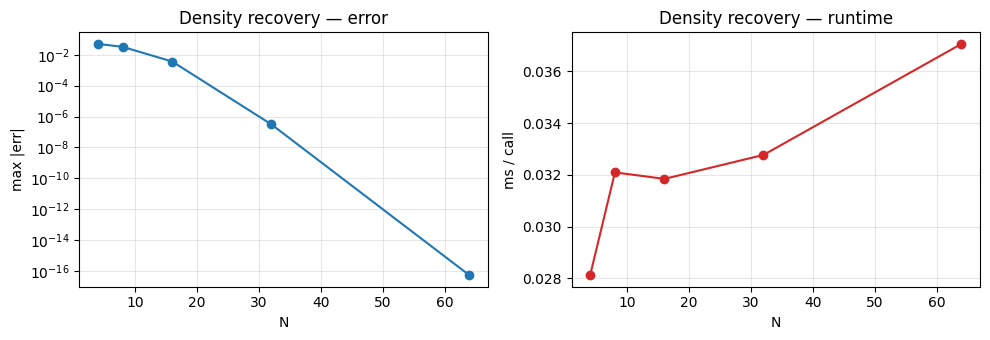

,N,max |err|,ms/call
0,4,0.04999851328,0.02811807999
1,8,0.03208835846,0.03209349001
2,16,0.003606738837,0.03184193999
3,32,3.151075349e-07,0.03276778001
4,64,5.50397774e-17,0.03706304999


In [23]:
def cf_normal(w):
    return np.exp(-0.5 * w**2)

def density_recover(N, a=-10.0, b=10.0, x_eval=np.array([-5.0, 5.0])):
    ba = b - a
    k  = np.arange(N)
    u  = k * np.pi / ba
    Fk = (2.0 / ba) * (cf_normal(u) * np.exp(-1j * u * a)).real
    Fk[0] *= 0.5
    theta = np.outer((x_eval - a) / ba * np.pi, k)
    return np.cos(theta) @ Fk

ref = norm.pdf(np.array([-5.0, 5.0]))
Ns  = [4, 8, 16, 32, 64]
rows = []
for N in Ns:
    err = float(np.max(np.abs(density_recover(N) - ref)))
    reps = 10_000
    t0   = time.perf_counter()
    for _ in range(reps):
        density_recover(N)
    ms = (time.perf_counter() - t0) / reps * 1e3
    rows.append((N, err, ms))
df_tbl1 = pd.DataFrame(rows, columns=["N", "max |err|", "ms/call"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.5))
a1.semilogy(df_tbl1["N"], df_tbl1["max |err|"], "o-", color="#1f77b4")
a1.set(xlabel="N", ylabel="max |err|", title="Density recovery — error")
a1.grid(True, which="both", alpha=0.3)
a2.plot(df_tbl1["N"], df_tbl1["ms/call"], "o-", color="#d62728")
a2.set(xlabel="N", ylabel="ms / call", title="Density recovery — runtime")
a2.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

df_tbl1

## 5.2 &nbsp; Table 2 — COS vs Carr-Madan under BSM

Classic head-to-head: GBM with `σ=0.25`, `r=0.1`, `q=0`, `T=0.1`, `S=100`,
strikes `{80, 100, 120}`. COS saturates at machine precision almost
immediately; Carr-Madan needs a much larger N to compete.

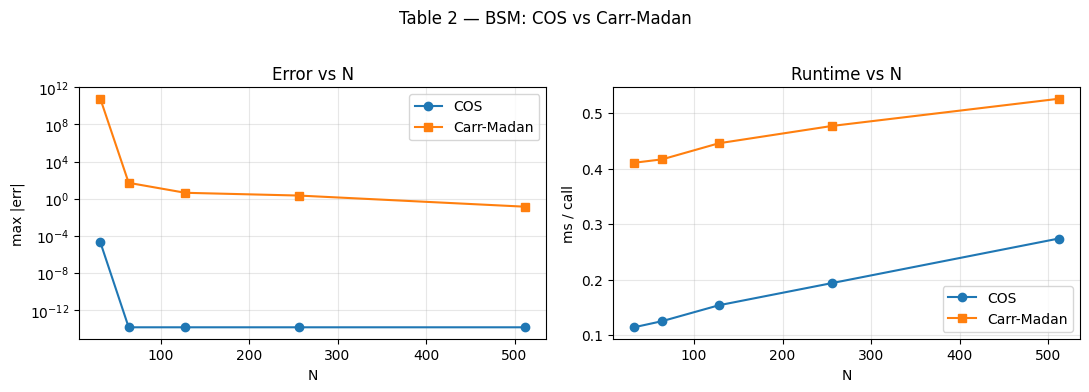

,N,COS max|err|,COS ms,CM max|err|,CM ms
0,32,2.045562959e-05,0.1142222,5.915205512e+10,0.4109011501
1,64,1.421085472e-14,0.12535695,51.87629345,0.41714125
2,128,1.421085472e-14,0.15397515,4.384031272,0.4461089
3,256,1.421085472e-14,0.19401725,2.214343277,0.4773713001
4,512,1.421085472e-14,0.2742788,0.1391380969,0.52635355


In [24]:
sig_t2, r_t2, q_t2, T_t2, S_t2 = 0.25, 0.1, 0.0, 0.1, 100.0
strikes_t2 = np.array([80.0, 100.0, 120.0])
ref_t2     = bsm_price(strikes_t2, S_t2, sig_t2, T_t2, r_t2, q_t2, cp=+1)

m_t2    = BsmModel(sigma=sig_t2, intr=r_t2, divr=q_t2)
cf_t2   = m_t2.char_func(T_t2)
fwd_t2  = S_t2 * np.exp((r_t2 - q_t2) * T_t2)
df_t2   = np.exp(-r_t2 * T_t2)

Ns = [32, 64, 128, 256, 512]
rows = []
for N in Ns:
    # COS
    cos_p = m_t2.price(strikes_t2, S_t2, T_t2, cp=+1, n_cos=N)
    cos_e = float(np.max(np.abs(cos_p - ref_t2)))
    reps  = 2_000
    t0    = time.perf_counter()
    for _ in range(reps):
        m_t2.price(strikes_t2, S_t2, T_t2, cp=+1, n_cos=N)
    cos_ms = (time.perf_counter() - t0) / reps * 1e3

    # Carr-Madan
    cm_p = carr_madan_price(cf_t2, T_t2, strikes_t2, fwd_t2, df_t2, N=N)
    cm_e = float(np.max(np.abs(cm_p - ref_t2)))
    t0   = time.perf_counter()
    for _ in range(reps):
        carr_madan_price(cf_t2, T_t2, strikes_t2, fwd_t2, df_t2, N=N)
    cm_ms = (time.perf_counter() - t0) / reps * 1e3

    rows.append((N, cos_e, cos_ms, cm_e, cm_ms))

df_tbl2 = pd.DataFrame(rows, columns=["N", "COS max|err|", "COS ms",
                                       "CM max|err|",  "CM ms"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.semilogy(df_tbl2["N"], df_tbl2["COS max|err|"], "o-", label="COS",        color="#1f77b4")
a1.semilogy(df_tbl2["N"], df_tbl2["CM max|err|"],  "s-", label="Carr-Madan", color="#ff7f0e")
a1.set(xlabel="N", ylabel="max |err|", title="Error vs N")
a1.grid(True, which="both", alpha=0.3); a1.legend()
a2.plot(df_tbl2["N"], df_tbl2["COS ms"], "o-", label="COS",        color="#1f77b4")
a2.plot(df_tbl2["N"], df_tbl2["CM ms"],  "s-", label="Carr-Madan", color="#ff7f0e")
a2.set(xlabel="N", ylabel="ms / call", title="Runtime vs N")
a2.grid(True, alpha=0.3); a2.legend()
fig.suptitle("Table 2 — BSM: COS vs Carr-Madan", y=1.02); fig.tight_layout(); plt.show()

df_tbl2

## 5.3 &nbsp; Table 3 — cash-or-nothing digital under BSM

Discontinuous payoff — the kind the paper points to when making the
case that COS doesn't suffer from Gibbs oscillations as long as `ψ` is
computed analytically. Reference `K · df · N(d₂) = 0.27330649649…`.

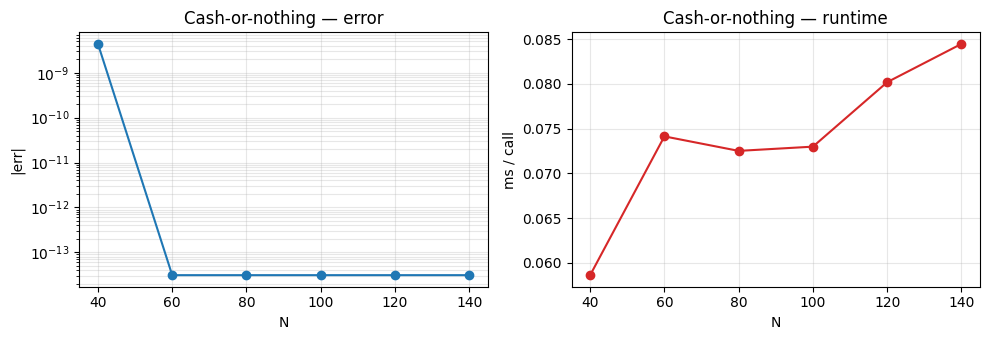

,N,COS price,|err|,ms/call
0,40,0.2733064921,4.404811849e-09,0.0586296001
1,60,0.2733064965,3.103073354e-14,0.07412614999
2,80,0.2733064965,3.103073354e-14,0.07250714989
3,100,0.2733064965,3.103073354e-14,0.07297939993
4,120,0.2733064965,3.103073354e-14,0.08017810003
5,140,0.2733064965,3.103073354e-14,0.08445329999


In [25]:
S_t3, K_t3, r_t3, q_t3, T_t3, sig_t3, L_t3 = 100.0, 120.0, 0.05, 0.0, 0.1, 0.2, 10.0
fwd_t3 = S_t3 * np.exp((r_t3 - q_t3) * T_t3)
df_t3  = np.exp(-r_t3 * T_t3)
d2     = (np.log(fwd_t3 / K_t3) - 0.5 * sig_t3**2 * T_t3) / (sig_t3 * np.sqrt(T_t3))
ref_t3 = K_t3 * df_t3 * norm.cdf(d2)

def cos_digital(N):
    # Analytic psi: integral of cos(k*pi*(x-a)/(b-a)) from log(K/F) to b.
    m   = BsmModel(sigma=sig_t3, intr=r_t3, divr=q_t3)
    cf  = m.char_func(T_t3)
    s2t = sig_t3**2 * T_t3
    c1  = -0.5 * s2t
    a, b = c1 - L_t3 * np.sqrt(s2t), c1 + L_t3 * np.sqrt(s2t)
    ba  = b - a
    k   = np.arange(N)
    u   = k * np.pi / ba
    phi = cf(u) * np.exp(-1j * u * a); phi[0] *= 0.5
    log_kf = float(np.clip(np.log(K_t3 / fwd_t3), a, b))
    safe_u = np.where(k == 0, 1.0, u)
    psi    = np.where(k == 0, b - log_kf,
                      (np.sin(u * (b - a)) - np.sin(u * (log_kf - a))) / safe_u)
    V = (2.0 / ba) * K_t3 * psi
    return df_t3 * float(V @ phi.real)

Ns = [40, 60, 80, 100, 120, 140]
rows = []
for N in Ns:
    p   = cos_digital(N)
    err = abs(p - ref_t3)
    reps = 2_000
    t0   = time.perf_counter()
    for _ in range(reps):
        cos_digital(N)
    ms = (time.perf_counter() - t0) / reps * 1e3
    rows.append((N, p, err, ms))
df_tbl3 = pd.DataFrame(rows, columns=["N", "COS price", "|err|", "ms/call"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.5))
a1.semilogy(df_tbl3["N"], df_tbl3["|err|"], "o-", color="#1f77b4")
a1.set(xlabel="N", ylabel="|err|", title="Cash-or-nothing — error")
a1.grid(True, which="both", alpha=0.3)
a2.plot(df_tbl3["N"], df_tbl3["ms/call"], "o-", color="#d62728")
a2.set(xlabel="N", ylabel="ms / call", title="Cash-or-nothing — runtime")
a2.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

df_tbl3

## 5.4 &nbsp; BSM dimensionless collapse

BSM with `r = q = 0` reduces to two dimensionless groups: `K/S₀` and
`σ√T`. The surface `C/S₀ = f(K/S₀, σ√T)` therefore contains every BSM
price under `r = q = 0`. Three very different raw triples are scattered
on top — all three land on the same surface, which is the visual
version of the π-theorem.

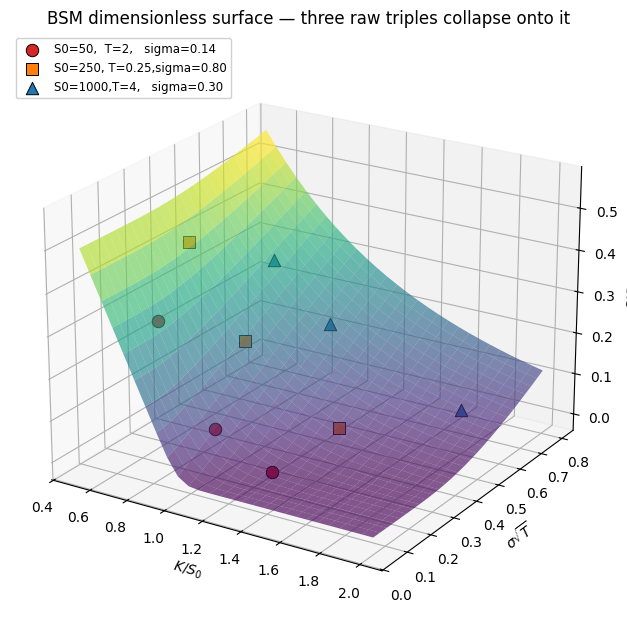

,K/S0,triple 1,triple 2,triple 3,spread
0,0.7,0.3337115189,0.3337115189,0.3337115189,4.662936703e-15
1,1,0.1585194189,0.1585194189,0.1585194189,3.663735981e-15
2,1.3,0.06939643304,0.06939643304,0.06939643304,4.357625372e-15
3,1.6,0.02947497422,0.02947497422,0.02947497422,6.775829897e-15


In [26]:
L_BSM = 20.0
N_K_s, N_V_s = 28, 28                         # reduce from 40 for notebook speed
k_over_s  = np.linspace(0.5, 2.0, N_K_s)
sig_sqT   = np.linspace(0.05, 0.8, N_V_s)
KK_s, VV_s = np.meshgrid(k_over_s, sig_sqT, indexing="ij")

def bsm_surface(S0, T, KK, VV):
    Kgrid = KK * S0
    sigma = VV / np.sqrt(T)
    Z = np.empty_like(Kgrid)
    for j in range(sigma.shape[1]):
        sig = float(sigma[0, j])
        m   = BsmModel(sigma=sig)
        a, b = m.trunc_range(T, L=L_BSM)
        Z[:, j] = cos_price(m.char_func(T), T, Kgrid[:, j],
                            fwd=S0, df=1.0, cp=+1, trunc_range=(a, b)) / S0
    return Z

Z_bsm = bsm_surface(100.0, 1.0, KK_s, VV_s)

triples = [
    ("S0=50,  T=2,   sigma=0.14",    50.0, 2.00, 0.14, np.array([0.7, 1.0, 1.3])),
    ("S0=250, T=0.25,sigma=0.80",   250.0, 0.25, 0.80, np.array([0.6, 0.9, 1.4])),
    ("S0=1000,T=4,   sigma=0.30",  1000.0, 4.00, 0.30, np.array([0.8, 1.1, 1.8])),
]

fig = plt.figure(figsize=(9, 6.5))
ax  = fig.add_subplot(111, projection="3d")
ax.plot_surface(KK_s, VV_s, Z_bsm, cmap="viridis", alpha=0.65,
                linewidth=0, antialiased=True)
colors  = ["#d62728", "#ff7f0e", "#1f77b4"]
markers = ["o", "s", "^"]
for i, (lbl, S0, T, sig, mn) in enumerate(triples):
    m  = BsmModel(sigma=sig)
    a, b = m.trunc_range(T, L=L_BSM)
    px = cos_price(m.char_func(T), T, mn * S0, fwd=S0, df=1.0,
                   cp=+1, trunc_range=(a, b)) / S0
    ax.scatter(mn, np.full_like(mn, sig * np.sqrt(T)), px, s=80, color=colors[i],
               marker=markers[i], edgecolor="black", linewidth=0.7,
               label=lbl, depthshade=False)
ax.set(xlabel=r"$K/S_0$", ylabel=r"$\sigma\sqrt{T}$", zlabel=r"$C/S_0$")
ax.set_title("BSM dimensionless surface — three raw triples collapse onto it")
ax.view_init(elev=22, azim=-58)
ax.legend(loc="upper left", fontsize=8.5, framealpha=0.92)
fig.tight_layout(); plt.show()

# Numeric collapse check at a common pi-point (sigma*sqrt(T) = 0.4)
common = [(50.0, 2.00, 0.4 / np.sqrt(2.00)),
          (250.0, 0.25, 0.4 / np.sqrt(0.25)),
          (1000., 4.00, 0.4 / np.sqrt(4.00))]
mn_grid = np.array([0.7, 1.0, 1.3, 1.6])
rows = []
for moneyness in mn_grid:
    row = [moneyness]
    for S0, T, sig in common:
        m = BsmModel(sigma=sig)
        a, b = m.trunc_range(T, L=L_BSM)
        p = float(cos_price(m.char_func(T), T, moneyness * S0,
                            fwd=S0, df=1.0, cp=+1, trunc_range=(a, b)))
        row.append(p / S0)
    row.append(max(row[1:]) - min(row[1:]))
    rows.append(row)
pd.DataFrame(rows, columns=["K/S0", "triple 1", "triple 2", "triple 3", "spread"])

## 5.5 &nbsp; BSM vs Bachelier

Calibrate Bachelier's absolute volatility as `σₙ = S₀·σ` — the
small-move matching — and compare dimensionless prices on the same
plane. The gap is tiny near ATM and for small `σ√T`; it widens to a
few percent at the corners.

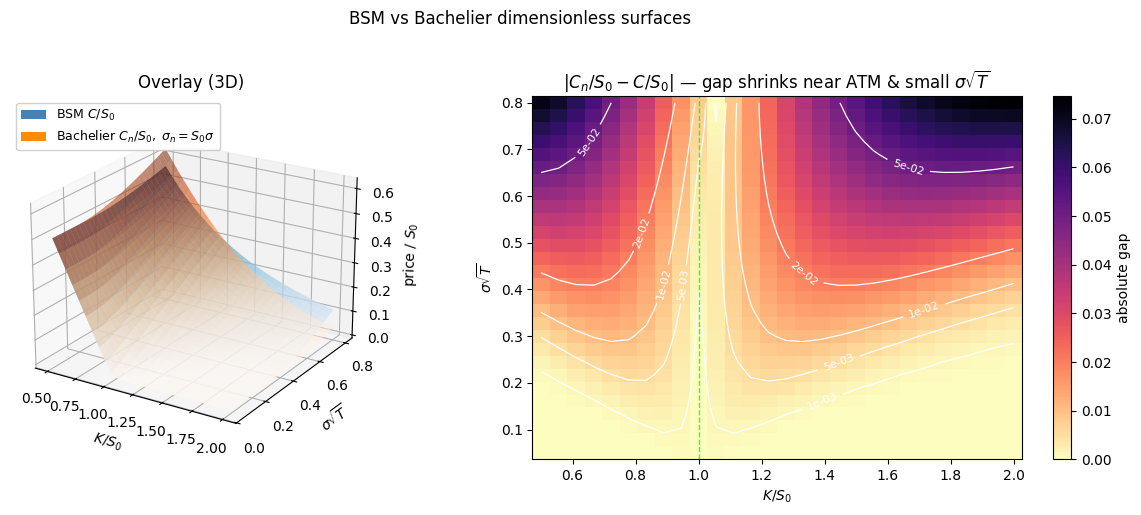

,region,max |gap|
0,overall,0.07462520075
1,"near ATM, small sigT",0.002125043733
2,far / large sigT,0.07462520075


In [27]:
L_NORM = 25.0

def bachelier_surface(S0, T, KK, VV):
    Kgrid = KK * S0
    sigma = VV / np.sqrt(T)
    Z = np.empty_like(Kgrid)
    for j in range(sigma.shape[1]):
        sig_n = float(sigma[0, j]) * S0
        m = NormalCos(sigma=sig_n)
        m.trunc_range = (lambda texp, _m=m, _L=L_NORM: _m.__class__.trunc_range(_m, texp, L=_L))
        Z[:, j] = m.price(Kgrid[:, j], S0, T, cp=+1) / S0
    return Z

Z_nml = bachelier_surface(100.0, 1.0, KK_s, VV_s)
gap   = Z_nml - Z_bsm

fig = plt.figure(figsize=(13, 5))

ax2a = fig.add_subplot(1, 2, 1, projection="3d")
ax2a.plot_surface(KK_s, VV_s, Z_bsm, cmap="Blues",   alpha=0.75,
                  linewidth=0, antialiased=True)
ax2a.plot_surface(KK_s, VV_s, Z_nml, cmap="Oranges", alpha=0.55,
                  linewidth=0, antialiased=True)
from matplotlib.patches import Patch
ax2a.legend(handles=[Patch(facecolor="steelblue",  label=r"BSM $C/S_0$"),
                     Patch(facecolor="darkorange", label=r"Bachelier $C_n/S_0,\ \sigma_n=S_0\sigma$")],
            loc="upper left", fontsize=9, framealpha=0.92)
ax2a.set(xlabel=r"$K/S_0$", ylabel=r"$\sigma\sqrt{T}$", zlabel=r"price / $S_0$")
ax2a.set_title("Overlay (3D)")
ax2a.view_init(elev=22, azim=-58)

ax2b = fig.add_subplot(1, 2, 2)
vmax = float(np.max(np.abs(gap)))
im   = ax2b.pcolormesh(KK_s, VV_s, np.abs(gap),
                       cmap="magma_r", vmin=0.0, vmax=vmax, shading="auto")
cs   = ax2b.contour(KK_s, VV_s, np.abs(gap),
                    levels=[1e-3, 5e-3, 1e-2, 2e-2, 5e-2],
                    colors="white", linewidths=0.9)
ax2b.clabel(cs, fontsize=8, fmt="%.0e")
ax2b.axvline(1.0, color="lime", linestyle="--", linewidth=1.0, alpha=0.8)
ax2b.set(xlabel=r"$K/S_0$", ylabel=r"$\sigma\sqrt{T}$",
         title=r"$|C_n/S_0 - C/S_0|$ — gap shrinks near ATM & small $\sigma\sqrt{T}$")
fig.colorbar(im, ax=ax2b, label="absolute gap")
fig.suptitle("BSM vs Bachelier dimensionless surfaces", y=1.02)
fig.tight_layout(); plt.show()

near_atm = (np.abs(KK_s - 1.0) < 0.10) & (VV_s < 0.20)
far      = (np.abs(KK_s - 1.0) > 0.40) | (VV_s > 0.60)
pd.DataFrame(
    [("overall",             float(np.max(np.abs(gap)))),
     ("near ATM, small sigT", float(np.max(np.abs(gap[near_atm])))),
     ("far / large sigT",     float(np.max(np.abs(gap[far]))))],
    columns=["region", "max |gap|"],
)

## 5.6 &nbsp; Heston dimensionless collapse

Same story, one more dimension. Heston has eight independent
π-groups; we fix six (`ρ`, `(r-q)T`, `κT`, `ūT`, `ηT`) and sweep the
remaining two (`K/S₀`, `√(v₀T)`). Three raw sextets at wildly
different `(S₀, T, v₀, κ, η, ū)` that realise the same six fixed
groups all land on the same slice.

Computing Heston surface (this takes a few seconds) ...


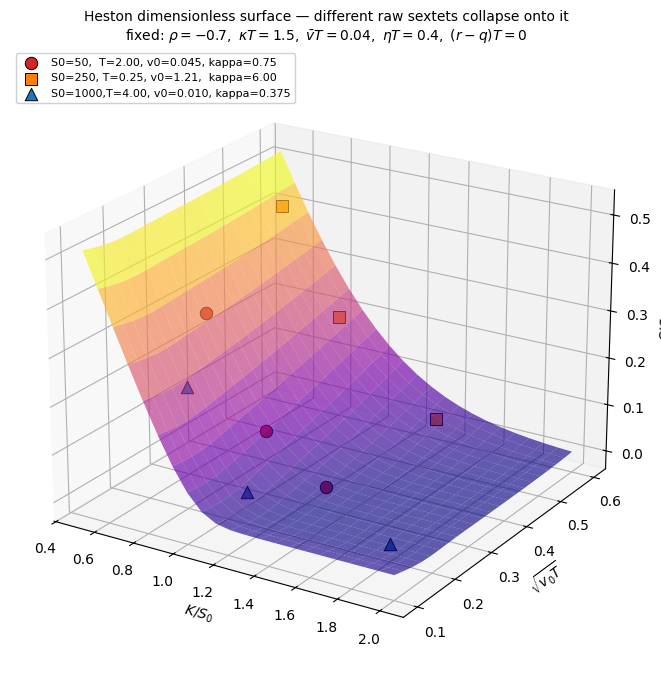

,K/S0,triple 1,triple 2,triple 3,spread
0,0.7,0.3243706886,0.3243706886,0.3243706886,0
1,1,0.1200870874,0.1200870874,0.1200870874,1.387778781e-17
2,1.3,0.02456841311,0.02456841311,0.02456841311,3.469446952e-18
3,1.6,0.002727298634,0.002727298634,0.002727298634,4.33680869e-19


In [28]:
PI_RHO, PI_RT       = -0.70, 0.0
PI_KAPPA_T, PI_UBAR_T = 1.50, 0.04
PI_ETA_T            = 0.40

N_Kh, N_Vh = 22, 22        # trim from 35 for notebook speed
k_over_sh  = np.linspace(0.5, 2.0, N_Kh)
sqrt_v0T   = np.linspace(0.10, 0.60, N_Vh)
KKh, VVh   = np.meshgrid(k_over_sh, sqrt_v0T, indexing="ij")

HALF_WIDTH_H, N_COS_H = 10.0, 256

def _make(S0, T, sigT):
    v0    = sigT**2 / T
    kappa = PI_KAPPA_T / T
    ubar  = PI_UBAR_T  / T
    eta   = PI_ETA_T   / T
    return HestonCOSPricer(S0=S0, v0=v0, lam=kappa, eta=eta, ubar=ubar,
                            rho=PI_RHO, r=PI_RT / T, q=0.0)

def _L_for(m):
    return HALF_WIDTH_H / float(np.sqrt(m.ubar + m.v0 * m.eta))

def heston_surface(S0, T, KK, VV):
    Kgrid = KK * S0
    Z = np.empty_like(Kgrid)
    for j in range(VV.shape[1]):
        m = _make(S0, T, float(VV[0, j]))
        Z[:, j] = m.price(Kgrid[:, j], T, cp=+1, N=N_COS_H, L=_L_for(m)) / S0
    return Z

print("Computing Heston surface (this takes a few seconds) ...")
Z_h = heston_surface(100.0, 1.0, KKh, VVh)

spread_specs = [
    (   50.0, 2.00, 0.30, np.array([0.7, 1.0, 1.3]), "S0=50,  T=2.00, v0=0.045, kappa=0.75"),
    (  250.0, 0.25, 0.55, np.array([0.6, 0.9, 1.4]), "S0=250, T=0.25, v0=1.21,  kappa=6.00"),
    ( 1000.0, 4.00, 0.20, np.array([0.8, 1.1, 1.8]), "S0=1000,T=4.00, v0=0.010, kappa=0.375"),
]

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")
ax.plot_surface(KKh, VVh, Z_h, cmap="plasma", alpha=0.65,
                linewidth=0, antialiased=True)
colors  = ["#d62728", "#ff7f0e", "#1f77b4"]
markers = ["o", "s", "^"]
for i, (S0, T, sigT, mn, lbl) in enumerate(spread_specs):
    m  = _make(S0, T, sigT)
    px = m.price(mn * S0, T, cp=+1, N=N_COS_H, L=_L_for(m)) / S0
    ax.scatter(mn, np.full_like(mn, sigT), px, s=80, color=colors[i],
               marker=markers[i], edgecolor="black", linewidth=0.7,
               label=lbl, depthshade=False)
ax.set(xlabel=r"$K/S_0$", ylabel=r"$\sqrt{v_0 T}$", zlabel=r"$C/S_0$")
ax.set_title("Heston dimensionless surface — different raw sextets collapse onto it\n"
             r"fixed: $\rho=-0.7,\ \kappa T=1.5,\ \bar v T=0.04,\ \eta T=0.4,\ (r-q)T=0$",
             fontsize=10)
ax.legend(loc="upper left", fontsize=8, framealpha=0.92)
ax.view_init(elev=22, azim=-58)
fig.tight_layout(); plt.show()

# Numeric collapse table at one common pi-point (sqrt(v0*T) = 0.4)
common = [(50.0, 2.00, 0.40), (250.0, 0.25, 0.40), (1000.0, 4.00, 0.40)]
mn_grid = np.array([0.7, 1.0, 1.3, 1.6])
rows = []
for moneyness in mn_grid:
    row = [moneyness]
    for S0, T, sigT in common:
        m = _make(S0, T, sigT)
        p = float(m.price(moneyness * S0, T, cp=+1, N=N_COS_H, L=_L_for(m)))
        row.append(p / S0)
    row.append(max(row[1:]) - min(row[1:]))
    rows.append(row)
pd.DataFrame(rows, columns=["K/S0", "triple 1", "triple 2", "triple 3", "spread"])

---
# 6. Error and runtime vs hyperparameters

One sweep per pricer, using a small shared timing helper. The
interesting axes are different for each model:

- BSM: `n_cos` only — one knob, exponential convergence.
- Heston: `N` at two maturities (T=1 and T=10) plus a sensitivity
  sweep in `L`. Long maturities need wider intervals.
- Variance Gamma: `n_cos` at T=1 (exponential) and T=0.1 (algebraic) —
  the same pricer in two different convergence regimes.
- Carr-Madan (BSM setup): `N` sweep — the natural competitor to COS.

Timings are per-call wall-clock in the current process. They're
indicative rather than publication-quality — rerun a cell to see the
noise floor.

In [29]:
def timed(fn, reps=None, min_reps=50, min_time=0.05):
    # Warm-up (numba-compiled kernels JIT on first call).
    fn()
    if reps is None:
        # Auto-calibrate: keep running until we hit min_time.
        n = min_reps
        while True:
            t0 = time.perf_counter()
            for _ in range(n):
                fn()
            dt = time.perf_counter() - t0
            if dt >= min_time or n >= 10_000:
                return dt / n * 1e3
            n *= 2
    t0 = time.perf_counter()
    for _ in range(reps):
        fn()
    return (time.perf_counter() - t0) / reps * 1e3

## 6.1 &nbsp; `BsmModel` — `n_cos` sweep

BSM converges exponentially; the error floor is set by floating-point
round-off, not by the COS truncation. Runtime is essentially flat
below N=512 because the dominant cost is array allocation, not the
matrix-vector product.

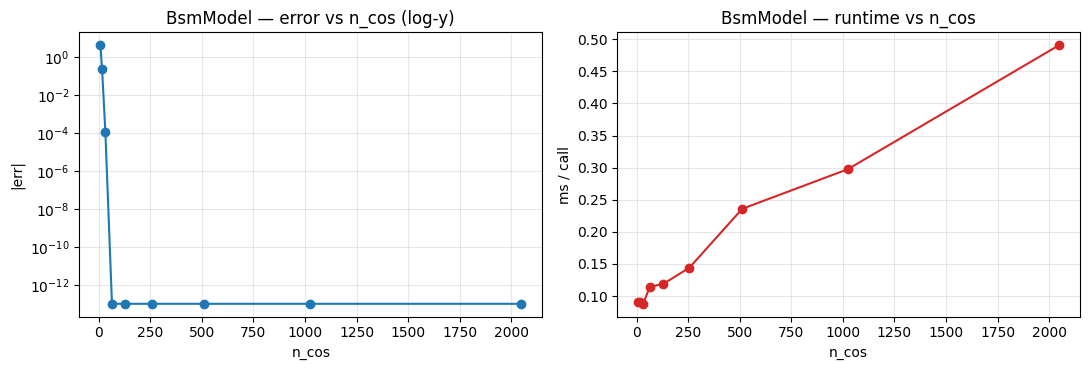

,n_cos,|err|,ms/call
0,8,4.352953006,0.09146662487
1,16,0.239425862,0.091139375
2,32,0.0001107838807,0.08798549999
3,64,1.003641614e-13,0.1146060001
4,128,1.003641614e-13,0.1186497501
5,256,1.003641614e-13,0.1442032499
6,512,1.003641614e-13,0.2358809998
7,1024,1.003641614e-13,0.2975554997
8,2048,1.003641614e-13,0.4906415008


In [30]:
sig_b, r_b, q_b, T_b, S_b, K_b = 0.2, 0.05, 0.1, 1.0, 100.0, 100.0
ref_b = bsm_price(K_b, S_b, sig_b, T_b, r_b, q_b)

model_b = BsmModel(sigma=sig_b, intr=r_b, divr=q_b)
Ns = [8, 16, 32, 64, 128, 256, 512, 1024, 2048]
rows = []
for N in Ns:
    err = abs(model_b.price(K_b, S_b, T_b, n_cos=N) - ref_b)
    ms  = timed(lambda N=N: model_b.price(K_b, S_b, T_b, n_cos=N))
    rows.append((N, err, ms))
df_b = pd.DataFrame(rows, columns=["n_cos", "|err|", "ms/call"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
# clamp tiny errs so semilogy doesn't get ugly
err_plot = np.maximum(df_b["|err|"], 1e-18)
a1.semilogy(df_b["n_cos"], err_plot, "o-", color="#1f77b4")
a1.set(xlabel="n_cos", ylabel="|err|", title="BsmModel — error vs n_cos (log-y)")
a1.grid(True, which="both", alpha=0.3)
a2.plot(df_b["n_cos"], df_b["ms/call"], "o-", color="#d62728")
a2.set(xlabel="n_cos", ylabel="ms / call", title="BsmModel — runtime vs n_cos")
a2.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

df_b

## 6.2 &nbsp; `HestonCOSPricer` — `N` sweep at two maturities, plus `L` sweep

Heston is the richest case. At T=1 convergence is fast in N; at T=10
you need more terms *and* a wider L to hit the same accuracy. The L
sweep is the other side of the truncation trade-off — too small and
the tail error dominates; too large and N has to grow to fill the
wider interval.

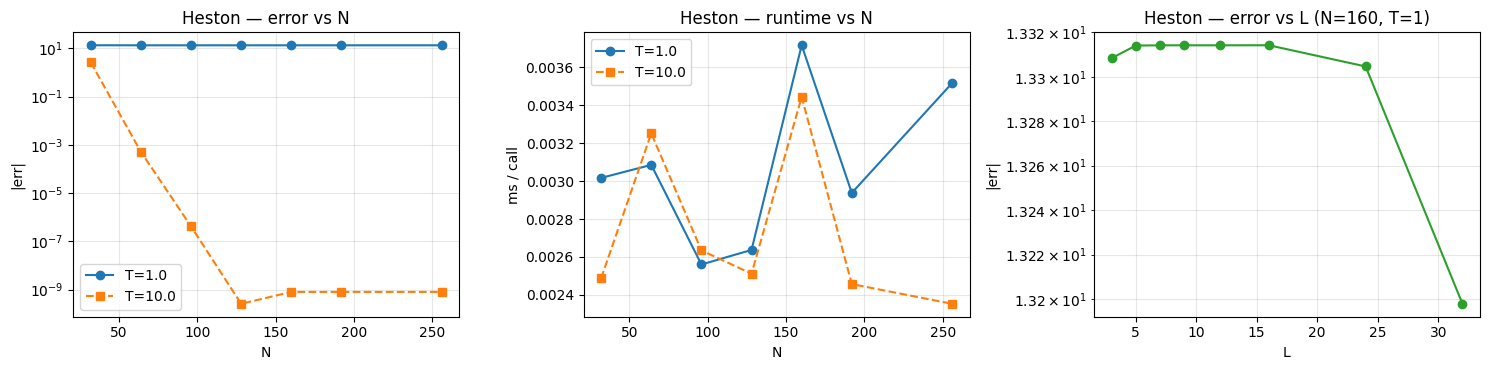

N sweep:


,T,N,|err|,ms/call
0,1,32,13.3678309,0.003016546889
1,10,32,2.608174285,0.002487851561
2,1,64,13.31362084,0.003085156241
3,10,64,0.0005160326567,0.00325125
4,1,96,13.31419466,0.002560265621
5,10,96,4.183074331e-07,0.002634609373
6,1,128,13.31419982,0.002637054677
7,10,128,2.59404942e-10,0.002511742186
8,1,160,13.31419924,0.003715609382
9,10,160,8.042988497e-10,0.003443335936


L sweep (N=160, T=1):


,L,|err|,ms/call
0,3,13.30834372,0.002875937498
1,5,13.31408774,0.003205914054
2,7,13.31419761,0.003266257809
3,9,13.31419927,0.002784195312
4,12,13.31419958,0.002145148428
5,16,13.31422496,0.003139617202
6,24,13.30465086,0.003676343749
7,32,13.19792941,0.002315460933


In [31]:
m_h = HestonCOSPricer(**PAPER_PARAMS)

# N sweep at T=1 and T=10
Ns = [32, 64, 96, 128, 160, 192, 256]
rows = []
for N in Ns:
    for T, ref in [(1.0, REF_T1), (10.0, REF_T10)]:
        err = abs(m_h.price_call(100.0, T, N=N) - ref)
        ms  = timed(lambda N=N, T=T: m_h.price_call(100.0, T, N=N))
        rows.append((T, N, err, ms))
df_h_N = pd.DataFrame(rows, columns=["T", "N", "|err|", "ms/call"])

# L sweep at fixed N=160, T=1
Ls = [3.0, 5.0, 7.0, 9.0, 12.0, 16.0, 24.0, 32.0]
rows = []
for L in Ls:
    err = abs(m_h.price_call(100.0, 1.0, N=160, L=L) - REF_T1)
    ms  = timed(lambda L=L: m_h.price_call(100.0, 1.0, N=160, L=L))
    rows.append((L, err, ms))
df_h_L = pd.DataFrame(rows, columns=["L", "|err|", "ms/call"])

fig, axs = plt.subplots(1, 3, figsize=(15, 3.8))
for T, style in [(1.0, "o-"), (10.0, "s--")]:
    sub = df_h_N[df_h_N["T"] == T]
    axs[0].semilogy(sub["N"], np.maximum(sub["|err|"], 1e-18), style, label=f"T={T}")
axs[0].set(xlabel="N", ylabel="|err|", title="Heston — error vs N")
axs[0].grid(True, which="both", alpha=0.3); axs[0].legend()

for T, style in [(1.0, "o-"), (10.0, "s--")]:
    sub = df_h_N[df_h_N["T"] == T]
    axs[1].plot(sub["N"], sub["ms/call"], style, label=f"T={T}")
axs[1].set(xlabel="N", ylabel="ms / call", title="Heston — runtime vs N")
axs[1].grid(True, alpha=0.3); axs[1].legend()

axs[2].semilogy(df_h_L["L"], np.maximum(df_h_L["|err|"], 1e-18), "o-", color="#2ca02c")
axs[2].set(xlabel="L", ylabel="|err|", title="Heston — error vs L (N=160, T=1)")
axs[2].grid(True, which="both", alpha=0.3)
fig.tight_layout(); plt.show()

print("N sweep:")
display(df_h_N)
print("L sweep (N=160, T=1):")
df_h_L

## 6.3 &nbsp; `VgModel` — `n_cos` sweep in two regimes

Same pricer, two wildly different convergence orders. T=1 is smooth
(exponential decay); T=0.1 has the short-time density kink
(algebraic). The `log10|err|` axis is linear in N for T=1 and linear
in `log10(N)` for T=0.1.

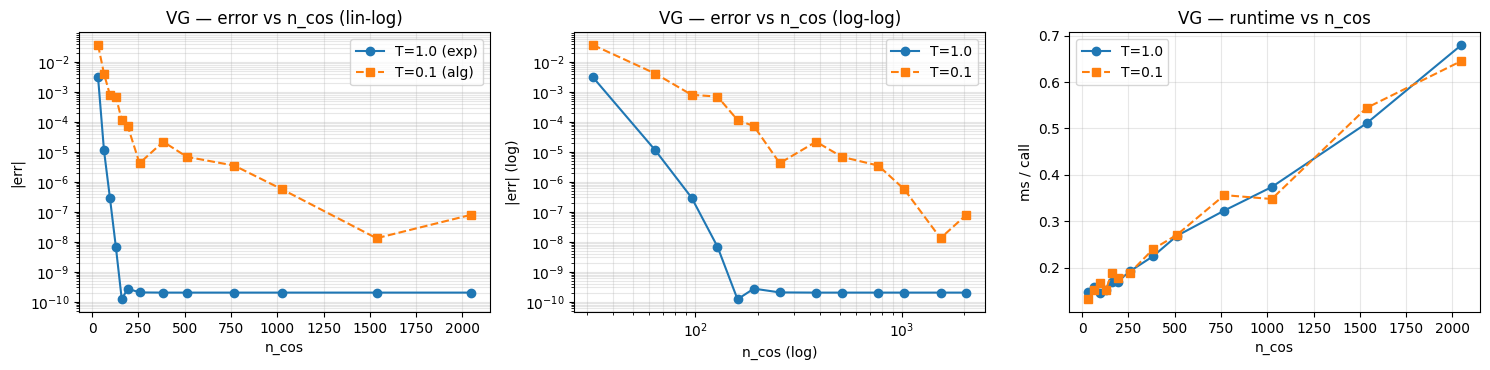

T=1.0:  slope(log10 |err| vs n_cos)        = -0.002   (exponential signature)
T=0.1:  slope(log10 |err| vs log10 n_cos)  = -3.281   (algebraic signature)


ms/call                        |err|                
T              0.1          1               0.1             1  
n_cos                                                          
32    0.1315104996    0.1473115   0.03643062398  0.003043060836
64    0.1515255001 0.1585157501  0.004069268262 1.126275857e-05
96    0.1675402495 0.1446964999 0.0007961862218 2.938664707e-07
128   0.1515927498 0.1525752502 0.0006969282147 6.857835189e-09
160   0.1879150001 0.1688989997 0.0001153061505 1.210871403e-10
192      0.1771235 0.1691967499 7.219718926e-05 2.742766014e-10
256     0.18778775 0.1914354996 4.185000602e-06 2.048778924e-10
384   0.2398537501   0.22455575 2.171810089e-05 2.020144052e-10
512     0.27048825 0.2683624998 6.800319483e-06 2.020570378e-10
768   0.3561214998     0.322895 3.474846057e-06 2.020570378e-10
1024  0.3477220004    0.3735775 5.694501812e-07 2.020570378e-10
1536  0.5442359997 0.5109670013 1.314969289e-08 2.020570378e-10
2048  0.6453689979 0.6798089994 7.979621053e-08 2.020570378e-10

In [32]:
vg_m = VgModel(sigma=SIGMA, theta=THETA, nu=NU, intr=R_vg, divr=Q_vg)

Ns = [32, 64, 96, 128, 160, 192, 256, 384, 512, 768, 1024, 1536, 2048]
rows = []
for N in Ns:
    for T, ref in [(1.0, REF_T1), (0.1, REF_T01)]:
        err = abs(vg_m.price(K_vg, S0_vg, T, n_cos=N) - ref)
        ms  = timed(lambda N=N, T=T: vg_m.price(K_vg, S0_vg, T, n_cos=N))
        rows.append((T, N, err, ms))
df_vg = pd.DataFrame(rows, columns=["T", "n_cos", "|err|", "ms/call"])

# regression slopes
sub1  = df_vg[df_vg["T"] == 1.0]
sub01 = df_vg[df_vg["T"] == 0.1]
slope_exp, *_ = linregress(sub1["n_cos"], np.log10(np.maximum(sub1["|err|"], 1e-18)))
slope_alg, *_ = linregress(np.log10(sub01["n_cos"]),
                           np.log10(np.maximum(sub01["|err|"], 1e-18)))

fig, axs = plt.subplots(1, 3, figsize=(15, 3.8))
axs[0].semilogy(sub1["n_cos"],  np.maximum(sub1["|err|"],  1e-18), "o-", label="T=1.0 (exp)")
axs[0].semilogy(sub01["n_cos"], np.maximum(sub01["|err|"], 1e-18), "s--", label="T=0.1 (alg)")
axs[0].set(xlabel="n_cos", ylabel="|err|", title="VG — error vs n_cos (lin-log)")
axs[0].grid(True, which="both", alpha=0.3); axs[0].legend()

axs[1].loglog(sub1["n_cos"],  np.maximum(sub1["|err|"],  1e-18), "o-", label="T=1.0")
axs[1].loglog(sub01["n_cos"], np.maximum(sub01["|err|"], 1e-18), "s--", label="T=0.1")
axs[1].set(xlabel="n_cos (log)", ylabel="|err| (log)", title="VG — error vs n_cos (log-log)")
axs[1].grid(True, which="both", alpha=0.3); axs[1].legend()

axs[2].plot(sub1["n_cos"],  sub1["ms/call"],  "o-", label="T=1.0")
axs[2].plot(sub01["n_cos"], sub01["ms/call"], "s--", label="T=0.1")
axs[2].set(xlabel="n_cos", ylabel="ms / call", title="VG — runtime vs n_cos")
axs[2].grid(True, alpha=0.3); axs[2].legend()
fig.tight_layout(); plt.show()

print(f"T=1.0:  slope(log10 |err| vs n_cos)        = {slope_exp:+.3f}   (exponential signature)")
print(f"T=0.1:  slope(log10 |err| vs log10 n_cos)  = {slope_alg:+.3f}   (algebraic signature)")
df_vg.pivot_table(index="n_cos", columns="T", values=["|err|", "ms/call"])

## 6.4 &nbsp; Carr-Madan FFT — `N` sweep on BSM

Damped FFT in log-strike. The error curve is the classic "need enough
N for the integrand to resolve" pattern — unlike COS, it takes more
than a few dozen points to hit sensible accuracy, because spline
interpolation onto the target strike costs an extra factor of
resolution. Runtime grows linearly in N (FFT on a larger grid plus
the spline).

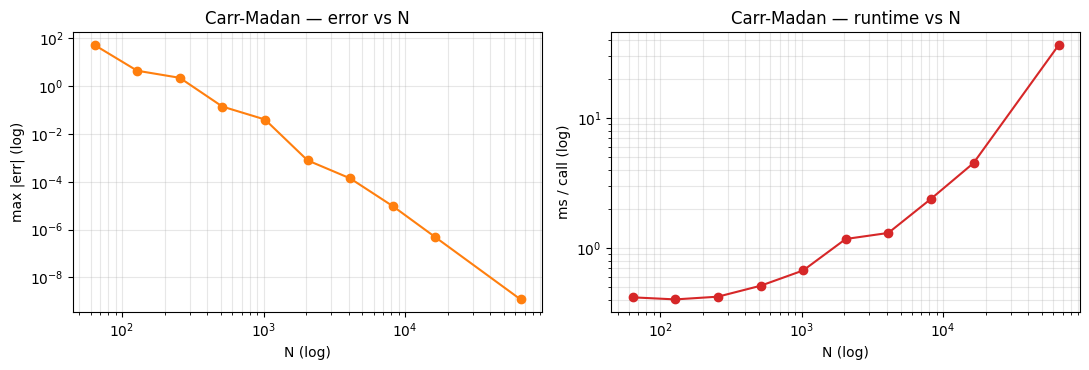

,N,max |err|,ms/call
0,64,51.87629345,0.4175015003
1,128,4.384031272,0.4025055002
2,256,2.214343277,0.4224444996
3,512,0.1391380969,0.5126839993
4,1024,0.04005472998,0.6725180009
5,2048,0.0007843039413,1.175824003
6,4096,0.0001384724088,1.309004002
7,8192,9.588486848e-06,2.394034001
8,16384,4.815935384e-07,4.521253998
9,65536,1.20875443e-09,36.7103


In [33]:
m_cm    = BsmModel(sigma=sig_t2, intr=r_t2, divr=q_t2)
cf_cm   = m_cm.char_func(T_t2)
fwd_cm  = S_t2 * np.exp((r_t2 - q_t2) * T_t2)
df_cm   = np.exp(-r_t2 * T_t2)
ref_cm  = bsm_price(strikes_t2, S_t2, sig_t2, T_t2, r_t2, q_t2, cp=+1)

Ns = [2**k for k in (6, 7, 8, 9, 10, 11, 12, 13, 14, 16)]
rows = []
for N in Ns:
    p   = carr_madan_price(cf_cm, T_t2, strikes_t2, fwd_cm, df_cm, N=N)
    err = float(np.max(np.abs(p - ref_cm)))
    ms  = timed(lambda N=N: carr_madan_price(cf_cm, T_t2, strikes_t2, fwd_cm, df_cm, N=N))
    rows.append((N, err, ms))
df_cm_sweep = pd.DataFrame(rows, columns=["N", "max |err|", "ms/call"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.loglog(df_cm_sweep["N"], np.maximum(df_cm_sweep["max |err|"], 1e-18),
          "o-", color="#ff7f0e")
a1.set(xlabel="N (log)", ylabel="max |err| (log)", title="Carr-Madan — error vs N")
a1.grid(True, which="both", alpha=0.3)
a2.loglog(df_cm_sweep["N"], df_cm_sweep["ms/call"], "o-", color="#d62728")
a2.set(xlabel="N (log)", ylabel="ms / call (log)", title="Carr-Madan — runtime vs N")
a2.grid(True, which="both", alpha=0.3)
fig.tight_layout(); plt.show()

df_cm_sweep

---
# Appendix — run the suite via pytest

Same tests as sections 1-4, delegated to pytest. Useful when you want
parametrise IDs, summary counts, or a non-zero exit code for CI.

In [34]:
import subprocess
repo_root = os.path.abspath(os.path.join(os.getcwd(),
    ".." if os.path.basename(os.getcwd()) == "notebooks" else "."))
env = dict(os.environ, PYTHONPATH=os.path.join(repo_root, "src"))
proc = subprocess.run(
    ["python", "-m", "pytest", "tests/", "-v", "--tb=short"],
    cwd=repo_root, env=env, capture_output=True, text=True,
)
print(proc.stdout[-4000:])
if proc.returncode != 0:
    print("STDERR:", proc.stderr[-2000:])

st_heston_spatial_temporal_invariance[1-call-0.5-0.5] PASSED [ 71%]
tests/test_heston_temporal_invariance.py::test_heston_spatial_temporal_invariance[1-call-0.5-2.0] PASSED [ 72%]
tests/test_heston_temporal_invariance.py::test_heston_spatial_temporal_invariance[1-call-0.5-10.0] PASSED [ 73%]
tests/test_heston_temporal_invariance.py::test_heston_spatial_temporal_invariance[1-call-2.0-0.5] PASSED [ 73%]
tests/test_heston_temporal_invariance.py::test_heston_spatial_temporal_invariance[1-call-2.0-2.0] PASSED [ 74%]
tests/test_heston_temporal_invariance.py::test_heston_spatial_temporal_invariance[1-call-2.0-10.0] PASSED [ 75%]
tests/test_heston_temporal_invariance.py::test_heston_spatial_temporal_invariance[1-call-100.0-0.5] PASSED [ 76%]
tests/test_heston_temporal_invariance.py::test_heston_spatial_temporal_invariance[1-call-100.0-2.0] PASSED [ 77%]
tests/test_heston_temporal_invariance.py::test_heston_spatial_temporal_invariance[1-call-100.0-10.0] PASSED [ 78%]
tests/test_heston_temporal_